Saving alejandro-contreras-wTPp323zAEw-unsplash.jpg to alejandro-contreras-wTPp323zAEw-unsplash.jpg


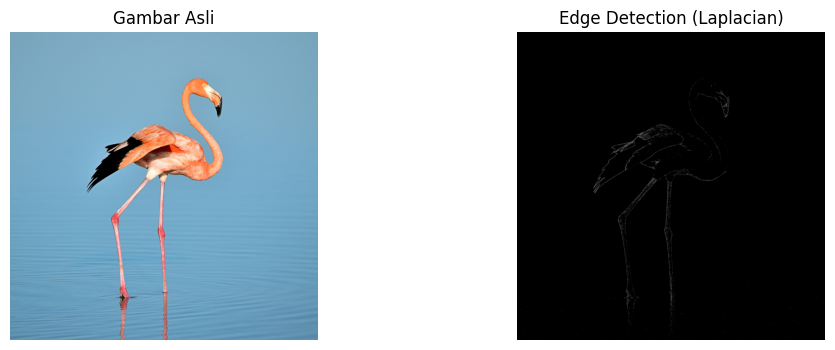

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import cv2
import numpy as np
from google.colab import files
import matplotlib.pyplot as plt

# Upload gambar
uploaded = files.upload()
filename = next(iter(uploaded))

# Baca gambar
image = cv2.imread(filename)

# Konversi ke grayscale untuk hasil yang lebih jelas
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Kernel Laplacian sederhana
kernel = np.array([[0, 1, 0],
                  [1, -4, 1],
                  [0, 1, 0]])

# Lakukan konvolusi
edge_detected = cv2.filter2D(gray, -1, kernel)

# Tingkatkan kontras hasil
edge_detected = cv2.convertScaleAbs(edge_detected)

# Optional: Threshold untuk mempertegas edges
_, edge_detected = cv2.threshold(edge_detected, 30, 255, cv2.THRESH_BINARY)

# Tampilkan hasil
plt.figure(figsize=(12,4))

plt.subplot(121)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Gambar Asli')
plt.axis('off')

plt.subplot(122)
plt.imshow(edge_detected, cmap='gray')
plt.title('Edge Detection (Laplacian)')
plt.axis('off')

plt.show()

# Simpan hasil
cv2.imwrite('edge_detected_laplacian.jpg', edge_detected)
files.download('edge_detected_laplacian.jpg')


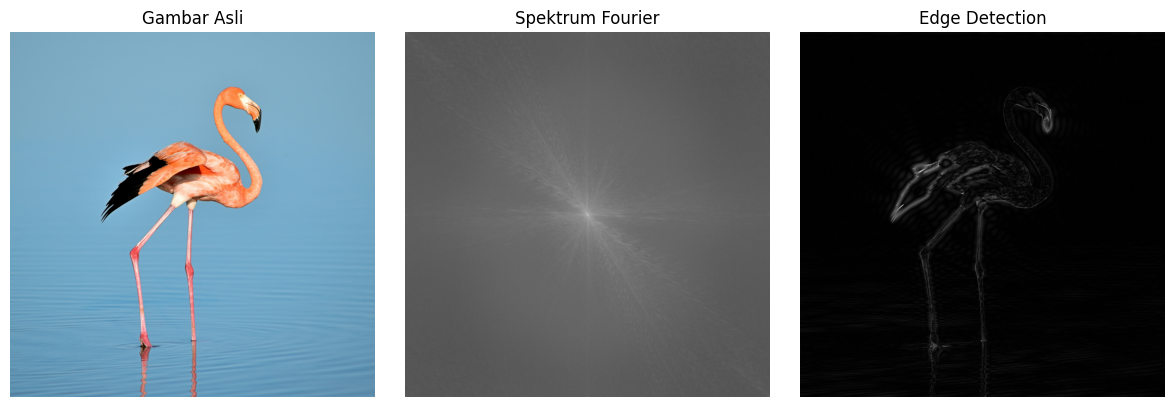

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Baca gambar
img = cv2.imread('angsa.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# Terapkan Transformasi Fourier
f = np.fft.fft2(gray)
fshift = np.fft.fftshift(f)
magnitude_spectrum = np.log(np.abs(fshift) + 1)

# Buat High-Pass Filter (HPF) untuk edge detection
rows, cols = gray.shape
crow, ccol = rows // 2, cols // 2
mask = np.ones((rows, cols), np.uint8)
r = 30  # Radius filter
cv2.circle(mask, (ccol, crow), r, 0, -1)  # Buat mask lingkaran inversi dari LPF

# Terapkan filter
fshift_filtered = fshift * mask
f_ishift = np.fft.ifftshift(fshift_filtered)
img_reconstructed = np.fft.ifft2(f_ishift)
img_reconstructed = np.abs(img_reconstructed)

# Normalisasi hasil untuk visualisasi yang lebih baik
img_reconstructed = cv2.normalize(img_reconstructed, None, 0, 255, cv2.NORM_MINMAX)

# Tampilkan hasil
plt.figure(figsize=(12, 4))

plt.subplot(131)
plt.imshow(img)
plt.title('Gambar Asli')
plt.axis('off')

plt.subplot(132)
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title('Spektrum Fourier')
plt.axis('off')

plt.subplot(133)
plt.imshow(img_reconstructed, cmap='gray')
plt.title('Edge Detection')
plt.axis('off')

plt.tight_layout()
plt.show()
